# **1. 서울 자전거 공유 수요 데이터셋**
서울시의 공공자전거 대여 서비스인 ‘따릉이’의 대여 수요를 예측하는 문제에 사용되는 [데이터셋](https://www.kaggle.com/datasets/joebeachcapital/seoul-bike-sharing/data)입니다. 특정 시간대와 날씨, 요일, 공휴일 여부, 기온, 습도 등 다양한 데이터를 활용하여 자전거 대여 수요를 예측합니다.

# **2. 데이터셋 컬럼**

- Date : 연월일
- Rented Bike count - 매 시간마다 대여한 자전거 수
- Hour - 하루 중 시간
- Temperature - 온도
- Humidity - 습도 %
- Windspeed - 풍속 m/s
- Visibility - 가시거리 m
- Dew point temperature - 이슬점 온도
- Solar radiation - 태양 복사 MJ/m2
- Rainfall - 강우량 mm
- Snowfall - 적설량 cm
- Seasons - 겨울, 봄, 여름, 가을
- Holiday - 휴일/휴일 없음
- Functional Day - 운영되지 않았던 날, 정상적으로 운영된 날

# **3. 데이터 전처리 및 탐색적 데이터 분석 (EDA)**

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# CP949
# Microsoft Windows의 한국어 문자 인코딩입니다.
# EUC-KR을 확장한 형태로, 더 많은 한국어 문자(한자, 확장 문자 등)를 지원합니다.
# 주로 Windows 환경에서 저장된 한글 파일에서 사용됩니다.
bike_df = pd.read_csv('/content/drive/MyDrive/2. AI활용 멀티모달 MCP PJ 시즌1/3. 머신러닝 딥러닝/data/SeoulBikeData.csv', encoding='cp949')
bike_df

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [46]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   object 
 12  Holiday                   8760 non-null   object 
 13  Functioning Day           8760 non-null   object 
dtypes: float

In [47]:
bike_df.describe()

,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [48]:
bike_df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(캜)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(캜)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

In [49]:
bike_df.columns = ['Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
       'Wind speed', 'Visibility', 'Dew point temperature',
       'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons',
       'Holiday', 'Functioning Day']

In [50]:
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


<Axes: xlabel='Temperature', ylabel='Rented Bike Count'>

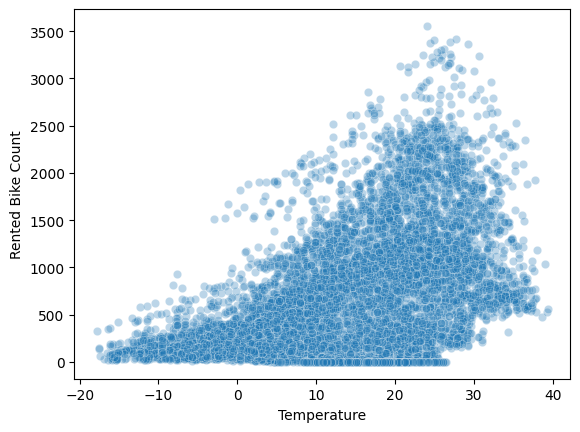

In [51]:
sns.scatterplot(x='Temperature', y='Rented Bike Count', data=bike_df, alpha=0.3)

<Axes: xlabel='Wind speed', ylabel='Rented Bike Count'>

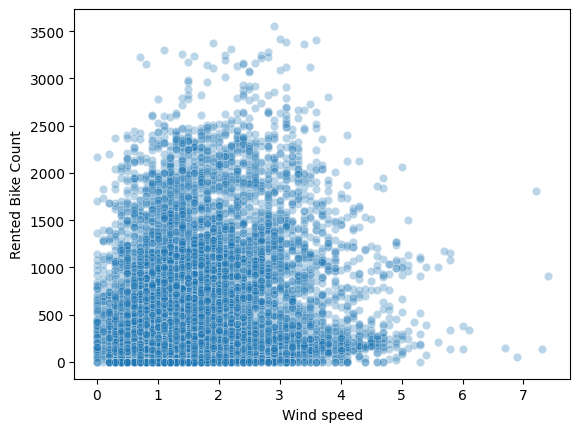

In [52]:
sns.scatterplot(x='Wind speed', y='Rented Bike Count', data=bike_df, alpha=0.3)

<Axes: xlabel='Visibility', ylabel='Rented Bike Count'>

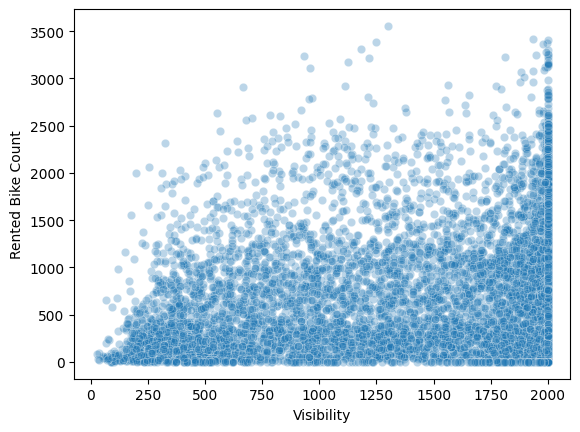

In [53]:
sns.scatterplot(x='Visibility', y='Rented Bike Count', data=bike_df, alpha=0.3)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

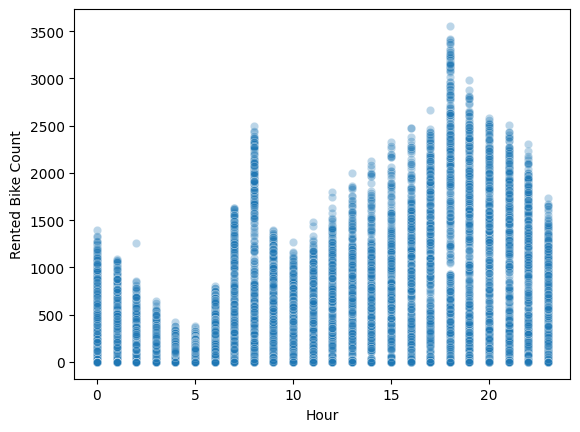

In [54]:
sns.scatterplot(x='Hour', y='Rented Bike Count', data=bike_df, alpha=0.3)

In [55]:
bike_df.isna().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature,0
Humidity,0
Wind speed,0
Visibility,0
Dew point temperature,0
Solar Radiation,0
Rainfall,0


In [56]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   object 
 12  Holiday                8760 non-null   object 
 13  Functioning Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ 

In [57]:
bike_df['Date'].head()

,Date
0,01/12/2017
1,01/12/2017
2,01/12/2017
3,01/12/2017
4,01/12/2017


In [58]:
bike_df['Date'] = pd.to_datetime(bike_df['Date'], format='%d/%m/%Y')
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   8760 non-null   datetime64[ns]
 1   Rented Bike Count      8760 non-null   int64         
 2   Hour                   8760 non-null   int64         
 3   Temperature            8760 non-null   float64       
 4   Humidity               8760 non-null   int64         
 5   Wind speed             8760 non-null   float64       
 6   Visibility             8760 non-null   int64         
 7   Dew point temperature  8760 non-null   float64       
 8   Solar Radiation        8760 non-null   float64       
 9   Rainfall               8760 non-null   float64       
 10  Snowfall               8760 non-null   float64       
 11  Seasons                8760 non-null   object        
 12  Holiday                8760 non-null   object        
 13  Fun

In [59]:
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day

In [60]:
bike_df

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30


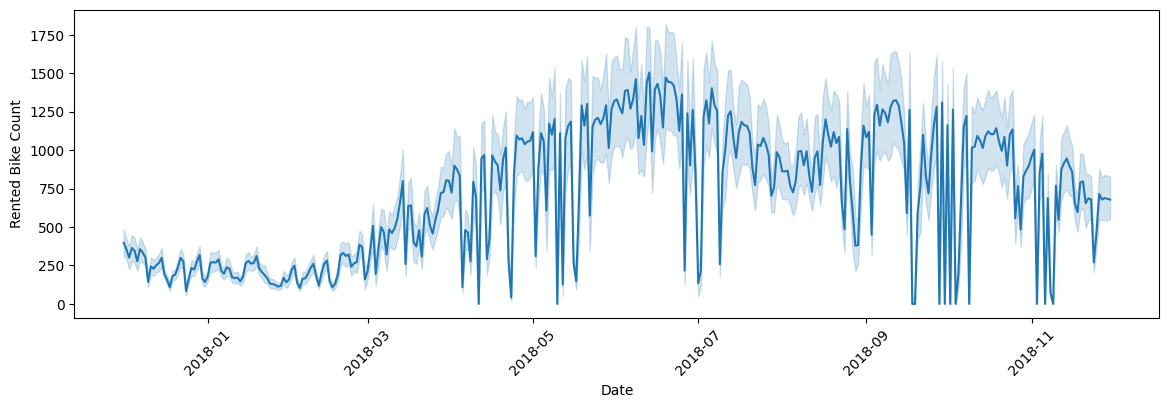

In [61]:
plt.figure(figsize=(14, 4))
sns.lineplot(x='Date', y='Rented Bike Count', data=bike_df)
plt.xticks(rotation=45)
plt.show()

In [62]:
bike_df[bike_df['year'] == 2017].groupby('month')['Rented Bike Count'].mean()

,Rented Bike Count
month,
12,249.099462


In [63]:
bike_df[bike_df['year'] == 2018].groupby('month')['Rented Bike Count'].mean()

,Rented Bike Count
month,
1,201.620968
2,225.941964
3,511.551075
4,728.093056
5,950.387097
6,1245.676389
7,987.177419
8,876.192204
9,935.572222


### ※ pd.cut()
pd.cut()은 숫자 데이터를 구간(bins)으로 나누어 범주형 데이터로 변환하는 데 사용됩니다. 주로 연속형 데이터를 특정 범주로 분류할 때 활용됩니다.

* 0 ≤ Hour ≤ 5	Dawn (새벽)
* 5 < Hour ≤ 11	Morning (아침)
* 11 < Hour ≤ 17	Afternoon (오후)
* 17 < Hour ≤ 23	Evening (저녁)

In [64]:
bike_df['TimeOfDay'] = pd.cut(bike_df['Hour'], bins=[0, 5, 11, 17, 23],
                              labels=['Dawn', 'Morning', 'Afternoon', 'Evening'],
                              include_lowest=True)

In [65]:
bike_df

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,TimeOfDay
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening


<Axes: xlabel='Functioning Day', ylabel='Rented Bike Count'>

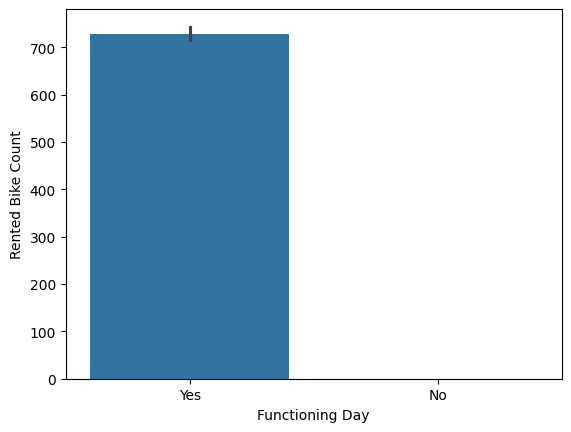

In [66]:
sns.barplot(x='Functioning Day', y='Rented Bike Count', data=bike_df)

Seaborn의 barplot은 범주형 데이터(x)에 대해 수치형 데이터(y)의 통계 요약값을 계산하여 막대로 시각화하는 그래프로, 기본적으로 각 범주별 평균(mean)을 사용하며 평균의 불확실성을 나타내는 신뢰구간(error bar)을 함께 표시합니다. 내부적으로는 groupby와 집계 과정을 자동으로 수행하여 원본 데이터의 개수와 상관없이 범주 수만큼의 막대가 생성되며, estimator 옵션을 통해 평균 대신 합계·중앙값·개수 등으로 변경할 수 있고, hue를 사용하면 추가 범주에 따른 비교도 가능합니다. 즉, seaborn barplot은 값 자체가 아니라 집단 간 통계적 대표값을 비교하기 위한 시각화 도구입니다.

### ※ Seaborn의 barplot 을 읽는 법

1. 먼저 “막대가 뭘 뜻하는지”부터 확인합니다. Seaborn barplot의 막대 높이는 기본적으로 평균(mean) 입니다.
- x축(또는 y축)에 있는 각 범주(category) 별로 y값(수치형)의 평균을 계산해서 그 평균을 막대 높이로 그립니다.
따라서 “막대가 높다” = 그 범주의 평균이 크다 입니다. (원본 데이터의 한 개 값이 아니라, “집단의 대표값”입니다.)



2. 축을 읽어 “무엇을 비교하는지”를 정합니다

- x축: 비교 대상(범주) → 예: 과일 종류, 요일, 지역, 등급
- y축: 비교 기준(수치) → 예: 판매량 평균, 점수 평균, 가격 평균


3) 막대끼리 비교할 때는 “차이의 크기”를 봅니다. 막대의 높이 차이를 보고 해석합니다.

- A 막대가 B보다 높다 → A의 평균이 더 크다
- 막대 차이가 크다 → 집단 간 평균 차이가 크다
- 비슷하다 → 큰 차이가 없다(적어도 평균 관점에서)
“평균이 비슷해도 데이터가 들쑥날쑥할 수 있다” → 그걸 보는 게 에러바입니다.



4. 에러바(error bar)는 “그 평균이 얼마나 믿을 만한지/흔들리는지”입니다. Seaborn barplot은 보통 막대 위아래에 선(에러바)가 그려집니다. 이 에러바는 설정에 따라 의미가 달라질 수 있지만(기본은 신뢰구간), 읽는 법은 공통입니다.

- 해석: 이 데이터를 기반으로, 유사한 100가지의 케이스에서 95개 이상은 해당 범위에서 결과를 얻음을 의미
- 평균(mean), 중앙값(median), 최빈값(mode)등의 다른 값들을 함께 고려했기 때문에 신뢰성 있는 수치임


In [67]:
bike_df['Functioning Day'].value_counts()

,count
Functioning Day,
Yes,8465
No,295


In [68]:
bike_df[bike_df['Functioning Day'] == 'Yes']

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,TimeOfDay
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,2018,11,30,Evening


In [69]:
bike_df[bike_df['Functioning Day'] == 'No']

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,TimeOfDay
3144,2018-04-11,0,0,14.4,82,4.6,1041,11.3,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3145,2018-04-11,0,1,13.6,81,3.6,886,10.3,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3146,2018-04-11,0,2,12.7,80,3.9,885,9.3,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3147,2018-04-11,0,3,11.6,81,3.1,687,8.4,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
3148,2018-04-11,0,4,10.2,83,3.5,554,7.4,0.0,0.0,0.0,Spring,No Holiday,No,2018,4,11,Dawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8251,2018-11-09,0,19,11.9,71,2.7,589,6.7,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening
8252,2018-11-09,0,20,11.9,72,2.5,526,7.0,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening
8253,2018-11-09,0,21,11.4,74,1.9,498,6.9,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening
8254,2018-11-09,0,22,11.2,75,1.7,478,6.9,0.0,0.0,0.0,Autumn,No Holiday,No,2018,11,9,Evening


<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

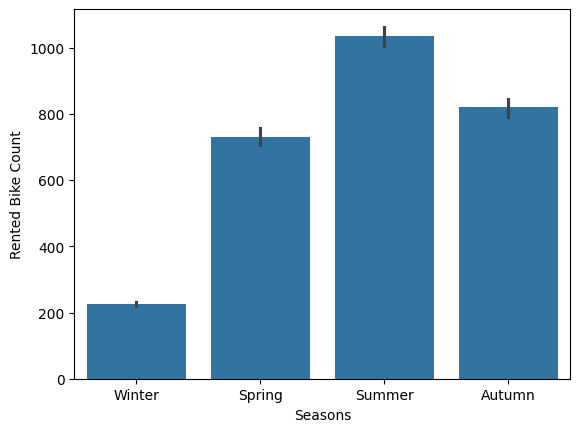

In [70]:
sns.barplot(x='Seasons', y='Rented Bike Count', data=bike_df)

In [71]:
bike_df['Seasons'].value_counts()

,count
Seasons,
Spring,2208
Summer,2208
Autumn,2184
Winter,2160


In [72]:
bike_df = bike_df.drop('Date', axis=1)
bike_df.head()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,TimeOfDay
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,Dawn


In [73]:
bike_df.select_dtypes(exclude=['number']).columns.tolist()

['Seasons', 'Holiday', 'Functioning Day', 'TimeOfDay']

In [74]:
for i in bike_df.select_dtypes(exclude=['number']).columns.tolist():
    print(i, bike_df[i].nunique())

Seasons 4
Holiday 2
Functioning Day 2
TimeOfDay 4


In [75]:
bike_df = pd.get_dummies(bike_df, columns=bike_df.select_dtypes(exclude=['number']).columns.tolist(), drop_first=True)
bike_df.head()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,...,month,day,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes,TimeOfDay_Morning,TimeOfDay_Afternoon,TimeOfDay_Evening
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,12,1,False,False,True,True,True,False,False,False
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,12,1,False,False,True,True,True,False,False,False
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,12,1,False,False,True,True,True,False,False,False
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,12,1,False,False,True,True,True,False,False,False
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,12,1,False,False,True,True,True,False,False,False


In [76]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Rented Bike Count      8760 non-null   int64  
 1   Hour                   8760 non-null   int64  
 2   Temperature            8760 non-null   float64
 3   Humidity               8760 non-null   int64  
 4   Wind speed             8760 non-null   float64
 5   Visibility             8760 non-null   int64  
 6   Dew point temperature  8760 non-null   float64
 7   Solar Radiation        8760 non-null   float64
 8   Rainfall               8760 non-null   float64
 9   Snowfall               8760 non-null   float64
 10  year                   8760 non-null   int32  
 11  month                  8760 non-null   int32  
 12  day                    8760 non-null   int32  
 13  Seasons_Spring         8760 non-null   bool   
 14  Seasons_Summer         8760 non-null   bool   
 15  Seas

### ※ corr() 함수
corr() 함수는 데이터프레임의 숫자형 열 간의 상관관계를 계산하는 데 사용됩니다. 상관관계는 두 변수 간의 선형 관계를 나타내며, 주로 -1에서 1 사이의 값으로 표현됩니다.

- corr()는 Pearson 상관계수를 기본으로 사용합니다.
- 숫자형 열만 상관관계 분석에 포함됩니다.
- 높은 상관관계(>|0.5|): 강한 관계
- 낮은 상관관계(<|0.2|): 약한 관계

> corr()를 사용하여 높은 상관관계를 가진 컬럼을 식별하고 제거할지 여부를 판단할 수 있습니다. 특히, 다중공선성(multicollinearity) 문제가 발생할 경우 머신러닝 모델의 성능이 저하될 수 있으므로, 상관관계가 높은 컬럼을 적절히 제거하는 것이 중요합니다.

### ※ 다중공선성

다중공선성(Multicollinearity)은 회귀 분석에서 독립 변수들(설명 변수) 간에 강한 상관관계가 존재하는 현상을 의미합니다. 이러한 상관관계가 높으면 각 독립 변수가 종속 변수에 미치는 개별적인 영향을 정확하게 추정하기 어려워지며, 회귀 계수의 추정치가 불안정해져 작은 데이터 변화에도 크게 변할 수 있습니다. 이는 모델의 예측 성능 저하와 해석의 신뢰성 감소로 이어질 수 있으므로, 다중공선성이 높은 변수를 식별하고 제거하거나 조정하는 것이 중요합니다.

In [77]:
# 모든 컬럼 간 상관관계 분석
correlation_matrix = bike_df.corr()
# correlation_matrix

# 목표 변수와의 상관관계만 확인
target_corr = correlation_matrix['Rented Bike Count'].sort_values(ascending=False)
print(target_corr)

Rented Bike Count        1.000000
Temperature              0.538558
Hour                     0.410257
Dew point temperature    0.379788
TimeOfDay_Evening        0.322978
Seasons_Summer           0.296549
Solar Radiation          0.261837
year                     0.215162
Functioning Day_Yes      0.203943
Visibility               0.199280
month                    0.133514
TimeOfDay_Afternoon      0.128639
Wind speed               0.121108
Holiday_No Holiday       0.072338
Seasons_Spring           0.022888
day                      0.022291
TimeOfDay_Morning       -0.081115
Rainfall                -0.123074
Snowfall                -0.141804
Humidity                -0.199780
Seasons_Winter          -0.424925
Name: Rented Bike Count, dtype: float64


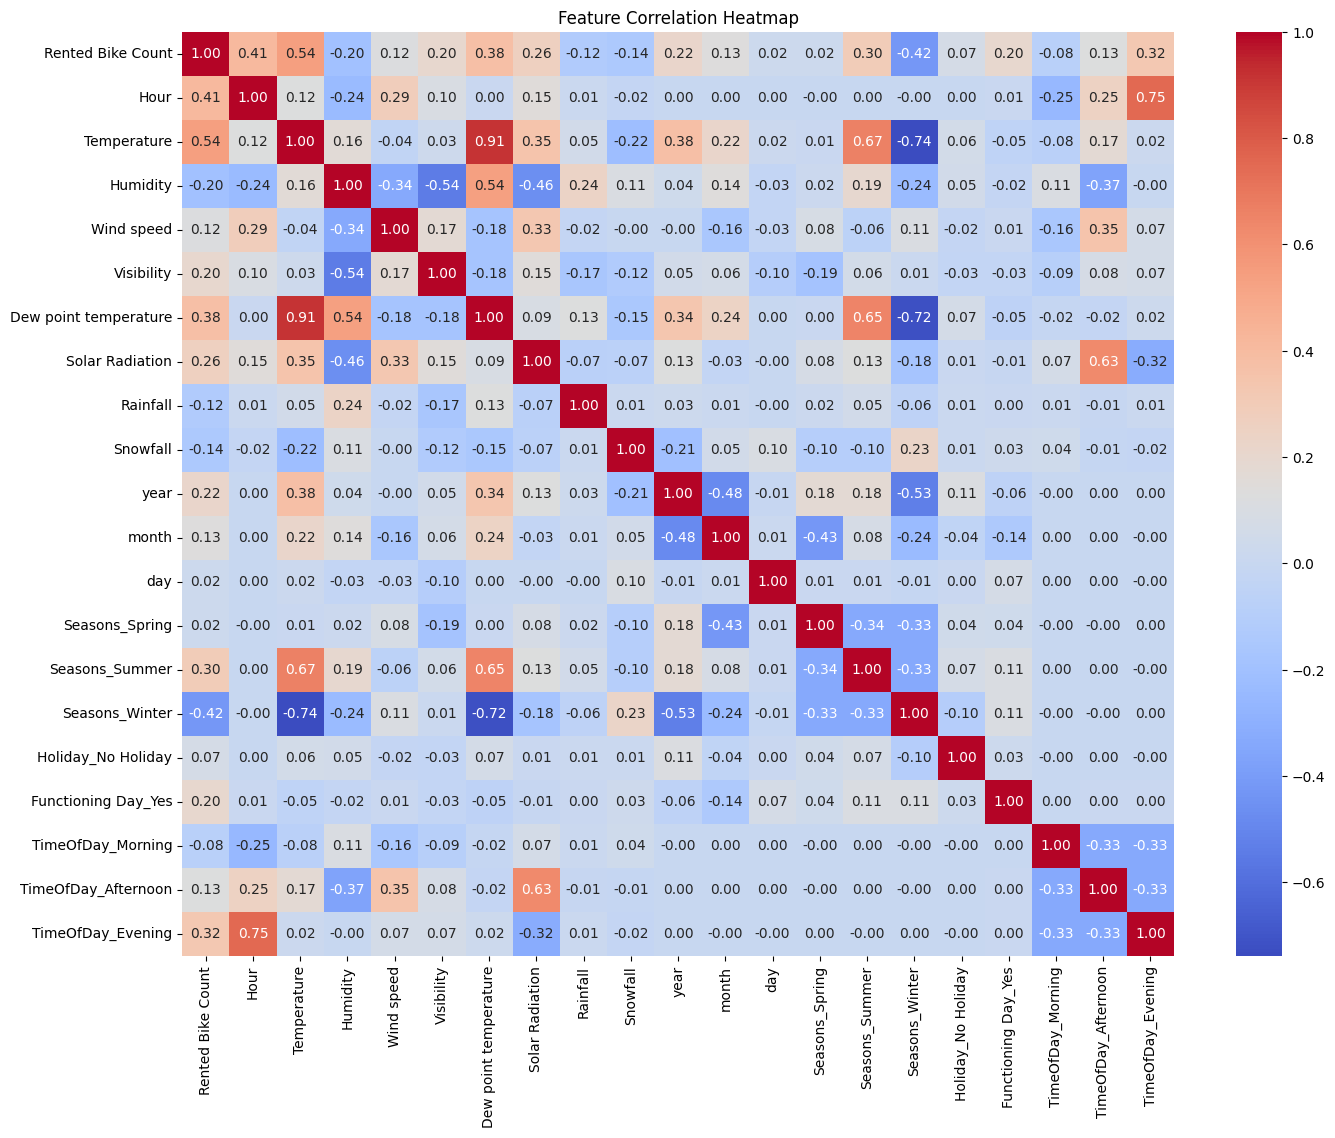

In [78]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

VIF(Variance Inflation Factor)
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지를 나타내는 값
- "해당 변수가 사실상 다른 변수들의 조합은 아닌가?"를 수치로 보여주는 지표
- 해석 기준
    - VIF < 5: 문제 없음
    - 5 <= VIF < 10: 주의
    - VIF >= 10: 다중 공선성 의심(조치 고려)

In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [80]:
X = bike_df.drop(columns=['Rented Bike Count'])
X = X.select_dtypes(include='number')
X = X.astype(float)
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values(by='VIF', ascending=False)

In [81]:
vif_df

,Feature,VIF
9,year,407.025112
1,Temperature,188.666573
2,Humidity,187.533688
5,Dew point temperature,126.954261
4,Visibility,10.788995
10,month,5.108772
3,Wind speed,4.890096
0,Hour,4.458880
11,day,4.379818
6,Solar Radiation,2.904971


In [82]:
bike_df = bike_df.drop(['Dew point temperature', 'Hour', 'Humidity', 'year'], axis=1)
bike_df.head()

,Rented Bike Count,Temperature,Wind speed,Visibility,Solar Radiation,Rainfall,Snowfall,month,day,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes,TimeOfDay_Morning,TimeOfDay_Afternoon,TimeOfDay_Evening
0,254,-5.2,2.2,2000,0.0,0.0,0.0,12,1,False,False,True,True,True,False,False,False
1,204,-5.5,0.8,2000,0.0,0.0,0.0,12,1,False,False,True,True,True,False,False,False
2,173,-6.0,1.0,2000,0.0,0.0,0.0,12,1,False,False,True,True,True,False,False,False
3,107,-6.2,0.9,2000,0.0,0.0,0.0,12,1,False,False,True,True,True,False,False,False
4,78,-6.0,2.3,2000,0.0,0.0,0.0,12,1,False,False,True,True,True,False,False,False


In [83]:
X = bike_df.drop(columns=['Rented Bike Count'])
X = X.select_dtypes(include='number')
X = X.astype(float)
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values(by='VIF', ascending=False)

vif_df

,Feature,VIF
2,Visibility,5.247050
6,month,4.211105
1,Wind speed,3.807370
7,day,3.292291
0,Temperature,2.758183
3,Solar Radiation,1.914448
5,Snowfall,1.116980
4,Rainfall,1.046290


In [84]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rented Bike Count    8760 non-null   int64  
 1   Temperature          8760 non-null   float64
 2   Wind speed           8760 non-null   float64
 3   Visibility           8760 non-null   int64  
 4   Solar Radiation      8760 non-null   float64
 5   Rainfall             8760 non-null   float64
 6   Snowfall             8760 non-null   float64
 7   month                8760 non-null   int32  
 8   day                  8760 non-null   int32  
 9   Seasons_Spring       8760 non-null   bool   
 10  Seasons_Summer       8760 non-null   bool   
 11  Seasons_Winter       8760 non-null   bool   
 12  Holiday_No Holiday   8760 non-null   bool   
 13  Functioning Day_Yes  8760 non-null   bool   
 14  TimeOfDay_Morning    8760 non-null   bool   
 15  TimeOfDay_Afternoon  8760 non-null   b

In [85]:
from sklearn.model_selection import train_test_split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(bike_df.drop('Rented Bike Count', axis=1),
                                                    bike_df['Rented Bike Count'], test_size=0.3,
                                                    random_state=2026)

In [88]:
X_train.shape, y_train.shape

((6132, 16), (6132,))

In [89]:
X_test.shape, y_test.shape

((2628, 16), (2628,))

# **4. 결정 나무**
결정 나무(Decision Tree)는 데이터를 기반으로 의사결정을 수행하는 트리 구조의 예측 모델입니다. 루트 노드(root node)에서 시작해 각 노드는 특정 특성(feature)의 조건에 따라 가지(branch)로 분기되며, 최종적으로 리프 노드(leaf node)에 도달해 예측 결과(클래스나 값)를 도출합니다. 주로 분류(Classification)와 회귀(Regression) 문제에 사용되며, 데이터의 패턴을 직관적으로 시각화할 수 있어 해석이 용이합니다. 하지만 트리가 너무 깊어지면 과적합(overfitting) 문제가 발생할 수 있으므로 가지치기(pruning)나 최대 깊이 설정 등으로 제어해야 합니다.


- 전체 데이터셋을 하나의 노드로 시작합니다.
- 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행합니다.
    - 분류 (Classification):
        - Gini 불순도(Gini Impurity)
        - 엔트로피(Entropy)
    - 회귀 (Regression):
        - 평균 제곱 오차(Mean Squared Error, MSE)
        - 절대 평균 오차(Mean Absolute Error, MAE)
- 각 하위 노드에 대해 위 단계를 반복합니다.
- 이 과정을 통해 트리는 여러 깊이로 성장합니다.
- 모든 노드가 더 이상 나눌 수 없거나 특정 조건(max_depth, min_samples_split)을 만족할 때까지 반복됩니다.
- 더 이상 분할이 불가능할 때 리프 노드가 생성됩니다.
    - 분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
    - 회귀 문제: 평균값을 예측값으로 사용

### ※ Gini 불순도 (Gini Impurity)

Gini 불순도는 한 노드에 있는 데이터의 순수도(Purity)를 측정하는 지표입니다.
한 노드에 있는 샘플들이 동일한 클래스에 속할 확률이 높을수록 Gini 불순도는 낮아집니다.
즉, 노드가 "얼마나 섞여 있는지"를 나타냅니다.

### ※ 엔트로피 (Entropy)

엔트로피는 정보의 불확실성(혼란도, Uncertainty)을 측정합니다.
엔트로피가 높을수록 해당 노드에 있는 데이터는 더 섞여 있으며, 예측하기 어렵습니다.
엔트로피는 데이터가 균등하게 분포될 때 최대값을 가집니다.

### ※ DecisionTreeRegressor

DecisionTreeRegressor는 주어진 데이터를 반복적으로 분할하여 예측을 수행합니다. 각 분할은 데이터의 목표 변수 값을 예측하는 데 가장 적합한 값을 찾기 위해 이루어집니다. 이를 통해 데이터를 점차 더 작은 부분으로 나누고, 각 부분에서 평균값을 예측값으로 사용하는 방식입니다. DecisionTreeRegressor  데이터를 두 가지 그룹으로 분할합니다. 각 분할에서 목표는 두 그룹의 MSE가 가능한 한 낮도록 만드는 것입니다. 즉, 각 분할에서의 MSE가 최소화되도록 분할점을 찾습니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fc5xBrw%2FbtsLJTOEd8U%2FAAAAAAAAAAAAAAAAAAAAAGws_seQ6mUxNomoGpWUIY4uvLkGlh5Wd3PQLjywZg5m%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3Dxm1bOdLAVY9y7IRrioxOaZM%252FgPY%253D'>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F0cO8I%2FbtsLJVyTmim%2FAAAAAAAAAAAAAAAAAAAAAHfyN8pCAPYUsPg1WDR2Ka-uzPLPEk6zgMBFG6esmYib%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3D%252Fvsm2ITwRbPj%252F8Yx%252BxTy3bJfGGU%253D'>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FbbwBFo%2FbtsLLNzuokO%2FAAAAAAAAAAAAAAAAAAAAAA1ETDxbCu3URIsQ9T3h9LC8VykMdxz_Re4ETHsdSTQx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3DsWtVkCTkeIoAyRJXeKdQIwyVLSs%253D'>


In [90]:
from sklearn.tree import DecisionTreeRegressor

In [91]:
dtr = DecisionTreeRegressor(random_state=2026)
dtr.fit(X_train, y_train)
pred1 = dtr.predict(X_test)

<Axes: xlabel='Rented Bike Count'>

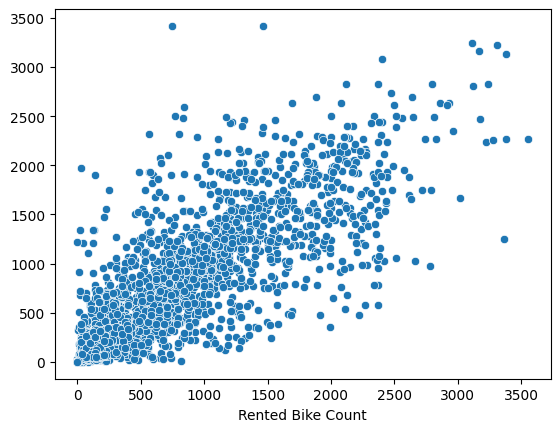

In [92]:
sns.scatterplot(x=y_test, y=pred1)

In [93]:
from sklearn.metrics import root_mean_squared_error

In [94]:
root_mean_squared_error(y_test, pred1)

386.77321542142454

In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred2 = lr.predict(X_test)

<Axes: xlabel='Rented Bike Count'>

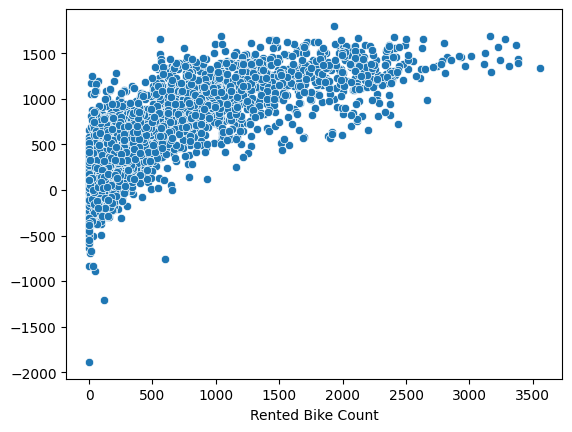

In [97]:
sns.scatterplot(x=y_test, y=pred2)

In [98]:
root_mean_squared_error(y_test, pred2)

446.47481228386397

* 결정나무: 386.77321542142454
* 선형회귀: 446.47481228386397

In [100]:
# 하이퍼 파라미터 적용
dtr = DecisionTreeRegressor(random_state=2026, max_depth=50,
                            min_samples_leaf=30)
dtr.fit(X_train, y_train)
pred3 = dtr.predict(X_test)

In [101]:
root_mean_squared_error(y_test, pred3)

334.1314843839107

* 결정나무: 386.77321542142454
* 선형회귀: 446.47481228386397
* 결정나무(하이퍼 파라미터 적용): 334.1314843839107

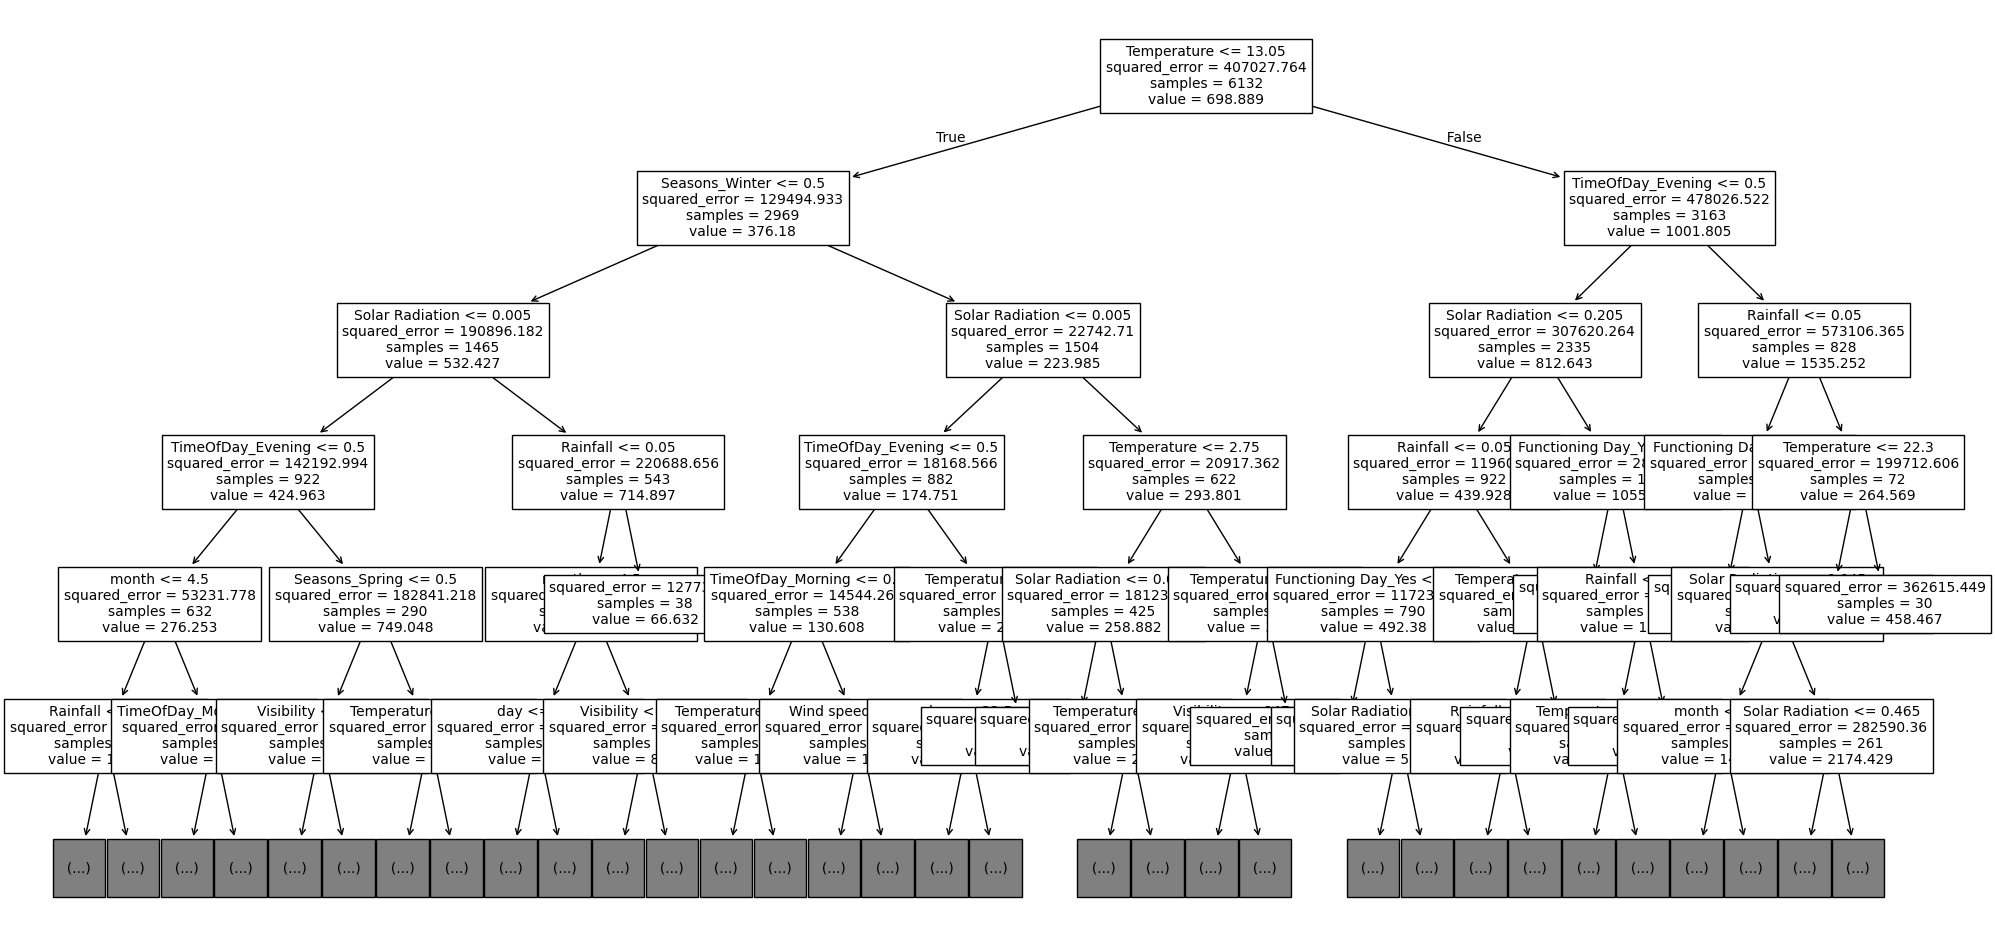

In [104]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(dtr, max_depth=5, fontsize=10, feature_names=X_train.columns)
plt.show()

In [105]:
from sklearn.ensemble import RandomForestRegressor

In [106]:
rf = RandomForestRegressor(random_state=2026)
rf.fit(X_train, y_train)
pred4 = rf.predict(X_test)
root_mean_squared_error(y_test, pred4)

288.8180227712803

* 결정나무: 386.77321542142454
* 선형회귀: 446.47481228386397
* 결정나무(하이퍼 파라미터 적용): 334.1314843839107
* 랜덤포레스트: 288.8180227712803

# **5. 피처 중요도**

In [107]:
rf.feature_importances_

array([0.33333296, 0.03471165, 0.04161041, 0.18998697, 0.07213078,
       0.0007097 , 0.03035888, 0.03378278, 0.00364607, 0.001982  ,
       0.01998755, 0.00170553, 0.08176585, 0.00652896, 0.00562147,
       0.14213844])

In [108]:
feature_imp = pd.DataFrame({
    'features': X_train.columns,
    'importances': rf.feature_importances_
})

In [109]:
feature_imp

,features,importances
0,Temperature,0.333333
1,Wind speed,0.034712
2,Visibility,0.041610
3,Solar Radiation,0.189987
4,Rainfall,0.072131
5,Snowfall,0.000710
6,month,0.030359
7,day,0.033783
8,Seasons_Spring,0.003646
9,Seasons_Summer,0.001982


In [110]:
top10 = feature_imp.sort_values('importances', ascending=False).head(10)
top10

,features,importances
0,Temperature,0.333333
3,Solar Radiation,0.189987
15,TimeOfDay_Evening,0.142138
12,Functioning Day_Yes,0.081766
4,Rainfall,0.072131
2,Visibility,0.041610
1,Wind speed,0.034712
7,day,0.033783
6,month,0.030359
10,Seasons_Winter,0.019988


<Axes: xlabel='importances', ylabel='features'>

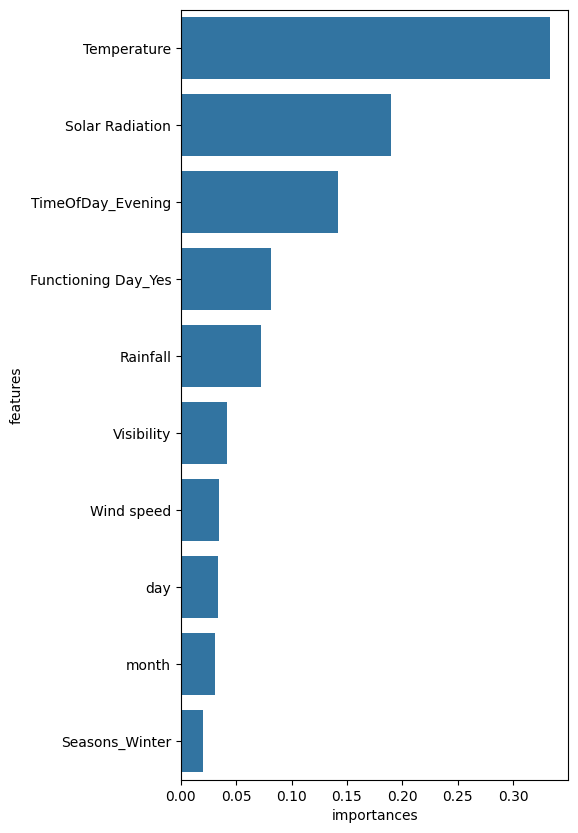

In [111]:
plt.figure(figsize=(5, 10))
sns.barplot(x='importances', y='features', data=top10)